# M2 Round 2A — Python-native EDA

Issue: [#26](../../../issues/26) — Round 2, Approach A of M2's EDA parallel track.

**Which Round 1 output this builds on, and why:** at the time this notebook was built, only
Round 1 Path A (Giti's sequential pull, PR #35) exists as working, reviewed output. Round 1 Path B
(Lerneir's concurrent client classes, issue #24) has no branch or PR yet, so there is no second
candidate to compare against — this notebook uses Path A's `data/processed/` output by default,
not by a judged comparison. If Path B lands before the Round 2 team sync, this choice should be
revisited.

**Scope** (per issue #26 definition of done): distributions, a missingness map, a correlation
matrix, ADF stationarity pre-checks, and at least 3 candidate figures with enough interpretation
to be useful to the rest of the team.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from statsmodels.tsa.stattools import adfuller

sns.set_theme(style="whitegrid")
PROJECT_ROOT = Path.cwd().resolve().parents[1]
PROCESSED = PROJECT_ROOT / "data" / "processed"
PROCESSED


PosixPath('/home/nholguin/projects/DAMO-699-Capstone-project-GRP5/data/processed')

## 1. Load the three processed sources

- `bank_of_canada_data.csv` — BoC policy/yield-curve series, daily, business days
- `fred_rates.csv` — US 10y treasury + fed funds rate, daily, business days
- `statcan_cpi.csv` — Canadian CPI, **monthly**, with both `reference_month` (the period the
  number describes) and `release_date` (when it was actually published — StatCan publishes CPI
  with roughly a 3-week lag)


In [2]:
boc = pd.read_csv(PROCESSED / "bank_of_canada_data.csv", parse_dates=["date"])
fred = pd.read_csv(PROCESSED / "fred_rates.csv", parse_dates=["date"])
cpi = pd.read_csv(PROCESSED / "statcan_cpi.csv", parse_dates=["reference_month", "release_date"])

for name, df in [("boc", boc), ("fred", fred), ("cpi", cpi)]:
    print(f"{name}: {df.shape}, {df.iloc[:, 0].min().date()} -> {df.iloc[:, 0].max().date()}")


boc: (4552, 12), 2009-01-02 -> 2026-06-30
fred: (4563, 3), 2009-01-02 -> 2026-06-30
cpi: (210, 3), 2009-01-01 -> 2026-06-01


## 2. Aligning three different frequencies onto one daily frame

BoC and FRED are both daily (business-day) series and merge on `date` directly. CPI is monthly
and, naively left-joined onto a daily index by `reference_month`, would show as "missing" on
every day that isn't the 1st of the month — that's not a data quality problem, it's a frequency
mismatch, and the missingness map in the next section would be misleading without correcting for
it here.

Instead, CPI is forward-filled onto the daily index keyed on **`release_date`**, not
`reference_month`: a CPI print only becomes actual public information on the day StatCan
publishes it (about 3 weeks after the reference month ends), so aligning on `reference_month`
would leak information the market didn't have yet on that date. This mirrors the release-date
mapping work already done in `config/cpi_release_dates.csv` (PR #35) and matters for any
downstream modeling that treats these as a real-time information set.


In [3]:
daily = boc.merge(fred, on="date", how="outer").sort_values("date")

# YoY inflation is computed at CPI's native monthly frequency (reference_month order) before
# merging — pct_change on the forward-filled daily series would divide by 250-253 varying
# business days per year instead of a clean 12-month lag, producing spurious jumps.
cpi_monthly = cpi.sort_values("reference_month").copy()
cpi_monthly["cpi_yoy"] = cpi_monthly["cpi_all_items"].pct_change(12) * 100

cpi_daily = cpi_monthly[["release_date", "cpi_all_items", "cpi_yoy"]].rename(columns={"release_date": "date"})
cpi_daily = cpi_daily.sort_values("date")

daily = daily.merge(cpi_daily, on="date", how="left").sort_values("date").reset_index(drop=True)
daily["cpi_all_items"] = daily["cpi_all_items"].ffill()
daily["cpi_yoy"] = daily["cpi_yoy"].ffill()

daily = daily.set_index("date")
daily.tail()


,overnight_rate,yield_2y,yield_3y,yield_5y,yield_7y,yield_10y,yield_long,usdcad_legacy,usdcad_current,usdcad,yield_spread_10y_2y,us_treasury_10y,fed_funds_rate,cpi_all_items,cpi_yoy
date,,,,,,,,,,,,,,,
2026-06-24,2.25,2.73,2.83,2.99,3.13,3.36,3.76,NaN,1.4234,1.4234,0.63,4.41,3.63,169.6,3.225806
2026-06-25,2.25,2.75,2.85,3.02,3.16,3.39,3.79,NaN,1.4204,1.4204,0.64,4.40,3.63,169.6,3.225806
2026-06-26,2.25,2.75,2.85,3.02,3.15,3.39,3.80,NaN,1.4186,1.4186,0.64,4.38,3.63,169.6,3.225806
2026-06-29,2.25,2.73,2.83,3.00,3.13,3.37,3.77,NaN,1.4206,1.4206,0.64,4.38,3.63,169.6,3.225806
2026-06-30,2.25,2.74,2.84,3.01,3.14,3.38,3.77,NaN,1.4210,1.4210,0.64,4.44,3.63,169.6,3.225806


### 🎤 Presentation readiness check — frequency alignment

Before presenting this section, make sure anyone on the team can answer:

1. Why is CPI aligned onto the daily frame using `release_date` instead of `reference_month`?
   What would go wrong for backtesting if we used `reference_month` instead?
2. StatCan publishes CPI roughly 3 weeks after the reference month ends. Why does that lag matter?
3. Why is YoY inflation computed with `pct_change(12)` on the **monthly** series instead of
   `pct_change(252)` on the daily forward-filled series? What specifically breaks with the daily
   version?

<details>
<summary>Show model answers</summary>

- **Q1:** `reference_month` is the period the number *describes*; `release_date` is when it became
  public. Joining on `reference_month` would let the model "see" a CPI print before StatCan
  actually published it — information leakage that would make backtests look better than any
  real-time strategy could actually perform.
- **Q2:** Any date before the release date has to use the *previous* month's CPI print, not the
  current one — the 3-week lag is why a naive join creates a block of dates where the "latest"
  CPI a market participant could see is older than you'd expect.
- **Q3:** `pct_change(252)` assumes exactly 252 business days between "now" and "one year ago,"
  but the real count varies (250–253) with holidays and leap years. On a series that's flat for
  ~21 business days between releases, that drift can pull the comparison across a release-date
  boundary, producing an artificial jump. `pct_change(12)` on the monthly series compares the
  correct calendar month every time.

</details>


## 3. Missingness map

Three distinct causes are expected, and the point of this map is to tell them apart rather than
flag everything as one undifferentiated "missing data" problem:

1. **`usdcad_legacy` / `usdcad_current`** — BoC switched USD/CAD series on 2017-05-01; each column
   is structurally null on the other side of that date by design (see PR #35). `usdcad` is the
   stitched column and should have far fewer gaps.
2. **`cpi_all_items` / `cpi_yoy`** — null only before the first CPI release date lands (start of
   sample) and for the first 12 months of releases, where `pct_change(12)` on the monthly series
   has no prior-year value to compare against; not a collection defect.
3. **Everything else (`yield_2y` … `us_treasury_10y`)** — small, scattered gaps (~180 rows out of
   ~4,550) most likely bank holidays that don't line up 1:1 between BoC/FRED calendars, worth a
   spot check but not a Round 1 blocker.


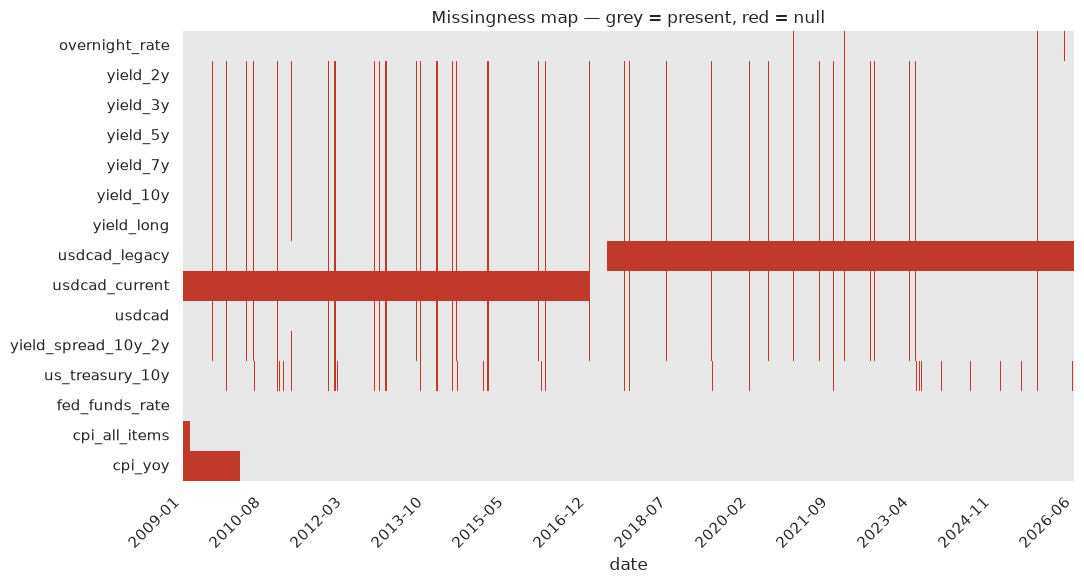

,n_missing,pct
overnight_rate,13,0.28
yield_2y,195,4.27
yield_3y,195,4.27
yield_5y,195,4.27
yield_7y,195,4.27
yield_10y,195,4.27
yield_long,195,4.27
usdcad_legacy,2478,54.31
usdcad_current,2194,48.08
usdcad,191,4.19


In [4]:
fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(daily.isna().T, cbar=False, cmap=["#e8e8e8", "#c0392b"], ax=ax)
ax.set_title("Missingness map — grey = present, red = null")
ax.set_xlabel("date")
tick_idx = np.linspace(0, len(daily) - 1, 12).astype(int)
ax.set_xticks(tick_idx)
ax.set_xticklabels(daily.index[tick_idx].strftime("%Y-%m"), rotation=45, ha="right")
fig.tight_layout()
plt.show()

daily.isna().sum().to_frame("n_missing").assign(pct=lambda d: (d["n_missing"] / len(daily) * 100).round(2))


### 🎤 Presentation readiness check — missingness

1. Name the three distinct causes of missing data in `daily`, in your own words.
2. Which of the three is missing *by design*, not because of a data problem?
3. Roughly what share of rows are affected by the unexplained holiday-calendar gaps?
4. Why is it wrong to just call `daily.dropna()` and move on, instead of understanding each cause
   separately first?

<details>
<summary>Show model answers</summary>

- **Q1:** (1) `usdcad_legacy`/`usdcad_current` — BoC switched series on 2017-05-01. (2)
  `cpi_all_items`/`cpi_yoy` — null only at the start of the sample before the first release, and
  during the 12-month YoY warm-up window. (3) Yield/rate columns — small scattered gaps from
  Canadian/US bank-holiday calendar mismatches.
- **Q2:** The USD/CAD legacy/current split — each column is structurally null on one side of the
  2017-05-01 methodology change by construction, not because of missing collection.
- **Q3:** ~180 rows out of ~4,552, or roughly 4%.
- **Q4:** A blind `dropna()` would silently discard ~4,550+ rows if applied before understanding
  that most of the "missingness" is either structural (USD/CAD split) or expected (CPI's monthly
  frequency) — you'd lose most of the dataset to handle a problem that mostly isn't one.

</details>


## 4. Yield curve overview

Before treating each tenor as an isolated feature column, look at the actual subject of this
project: the term structure itself, and the slope summary (`yield_spread_10y_2y`) that's used
throughout the proposal as the primary modeling target. The top panel overlays all six GoC tenors;
the bottom panel is the 10y-2y spread, with the inverted region shaded.


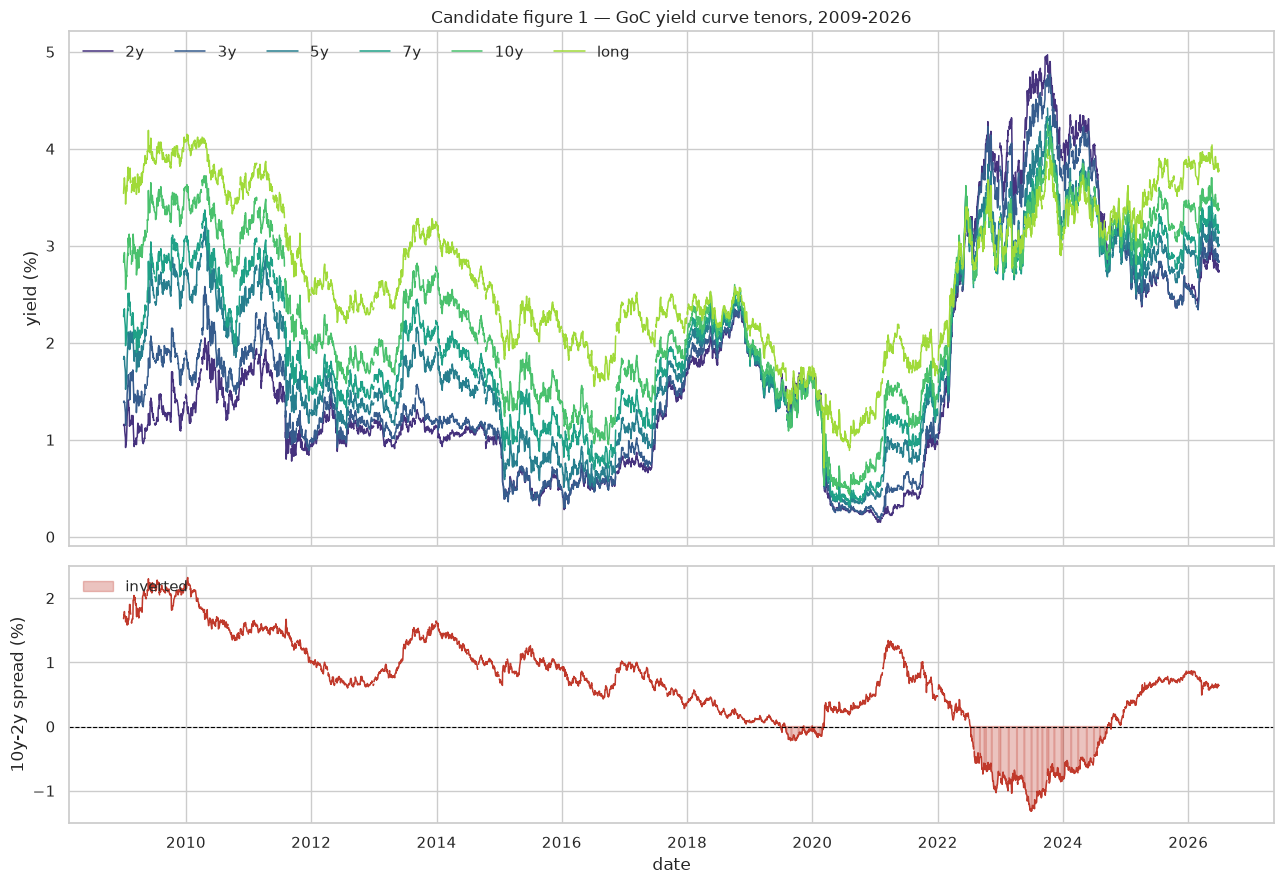

In [5]:
tenor_cols = ["yield_2y", "yield_3y", "yield_5y", "yield_7y", "yield_10y", "yield_long"]
fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True, gridspec_kw={"height_ratios": [2, 1]})

palette = sns.color_palette("viridis", n_colors=len(tenor_cols))
for col, color in zip(tenor_cols, palette):
    axes[0].plot(daily.index, daily[col], label=col.replace("yield_", ""), color=color, linewidth=1.1)
axes[0].set_ylabel("yield (%)")
axes[0].set_title("Candidate figure 1 — GoC yield curve tenors, 2009-2026")
axes[0].legend(ncol=6, loc="upper left", frameon=False)

axes[1].plot(daily.index, daily["yield_spread_10y_2y"], color="#c0392b", linewidth=1.1)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].fill_between(
    daily.index, daily["yield_spread_10y_2y"], 0,
    where=daily["yield_spread_10y_2y"] < 0, color="#c0392b", alpha=0.3, label="inverted",
)
axes[1].set_ylabel("10y-2y spread (%)")
axes[1].set_xlabel("date")
axes[1].legend(loc="upper left", frameon=False)

fig.tight_layout()
plt.show()


**Interpretation:** the curve flattens and inverts in two windows in this sample — briefly in
mid/late 2019, then repeatedly from mid-2022 through late 2024, where the spread crosses back and
forth across zero roughly three dozen times rather than staying inverted in one solid block (look
closely at the bottom panel — it's a series of short flips, not a single trough). That pattern is
consistent with the post-inflation-shock hiking cycle keeping the short end and long end in close,
unstable tension rather than one clean regime shift. As of the latest observation in this sample
(2026-06-30), the spread is +0.64 and the full curve is upward-sloping across every tenor pair —
**not currently inverted**. This is the chart that should anchor any discussion of
inversion-as-leading-indicator (Estrella & Hardouvelis, 1991, per `proposal/sections/05_analytical_approach.md`
§5.1) — the ADF and correlation results in the sections below describe the statistical behavior of
these series but say nothing on their own about which economic regime produced them.


### 🎤 Presentation readiness check — yield curve overview

This is the section most likely to get audience questions. Everyone should be able to answer these
cold, without pulling up the notebook:

1. Is the Canadian yield curve currently (last observation, 2026-06-30) inverted or normal? What
   number backs that up?
2. What is the full historical range of the 10y-2y spread (min/max) across the sample, and what
   does the negative extreme represent economically?
3. **Trap question:** true or false — the curve was continuously inverted from mid-2022 through
   2023. Look at the bottom panel closely before answering.
4. Looking at the latest snapshot across all six tenors, is the curve strictly increasing from
   2y to long (a "normal" upward-sloping curve), or is any segment flat/inverted?
5. Why is an inverted 10y-2y spread treated as a leading recession indicator? (One sentence,
   Expectations Hypothesis framing.)

<details>
<summary>Show model answers</summary>

- **Q1:** Normal/upward-sloping — the spread is **+0.64** on 2026-06-30, and it's positive
  (not inverted).
- **Q2:** Range is roughly **-1.32 to +2.32**. The negative extreme is the deepest inversion in
  the sample — short-term yields (2y) priced meaningfully above long-term yields (10y).
- **Q3:** **False.** The spread crosses zero repeatedly — roughly three dozen separate in/out
  flips between mid-2022 and late 2024 — rather than staying inverted in one continuous block.
  Getting this wrong live is the easiest way to lose credibility with an audience that's looking
  at the same chart.
- **Q4:** Strictly increasing on the latest date: 2y=2.74, 3y=2.84, 5y=3.01, 7y=3.14, 10y=3.38,
  long=3.77 — a textbook normal (upward-sloping) curve right now.
- **Q5:** An inverted curve means the market expects short-term rates to fall (e.g., because the
  central bank will cut in response to a slowing economy) more than it expects the long run to
  change — so short yields, which price near-term expectations more directly, rise above long
  yields.

</details>


## 5. Distributions

Levels for the policy-rate-adjacent series (`overnight_rate`, `fed_funds_rate`) are expected to be
strongly right-skewed / multi-modal — most of the sample sits in a near-zero-rate regime
(2009–2021), with a sharp regime shift after 2022. That shape is a preview of the stationarity
result in section 7, not a data issue.


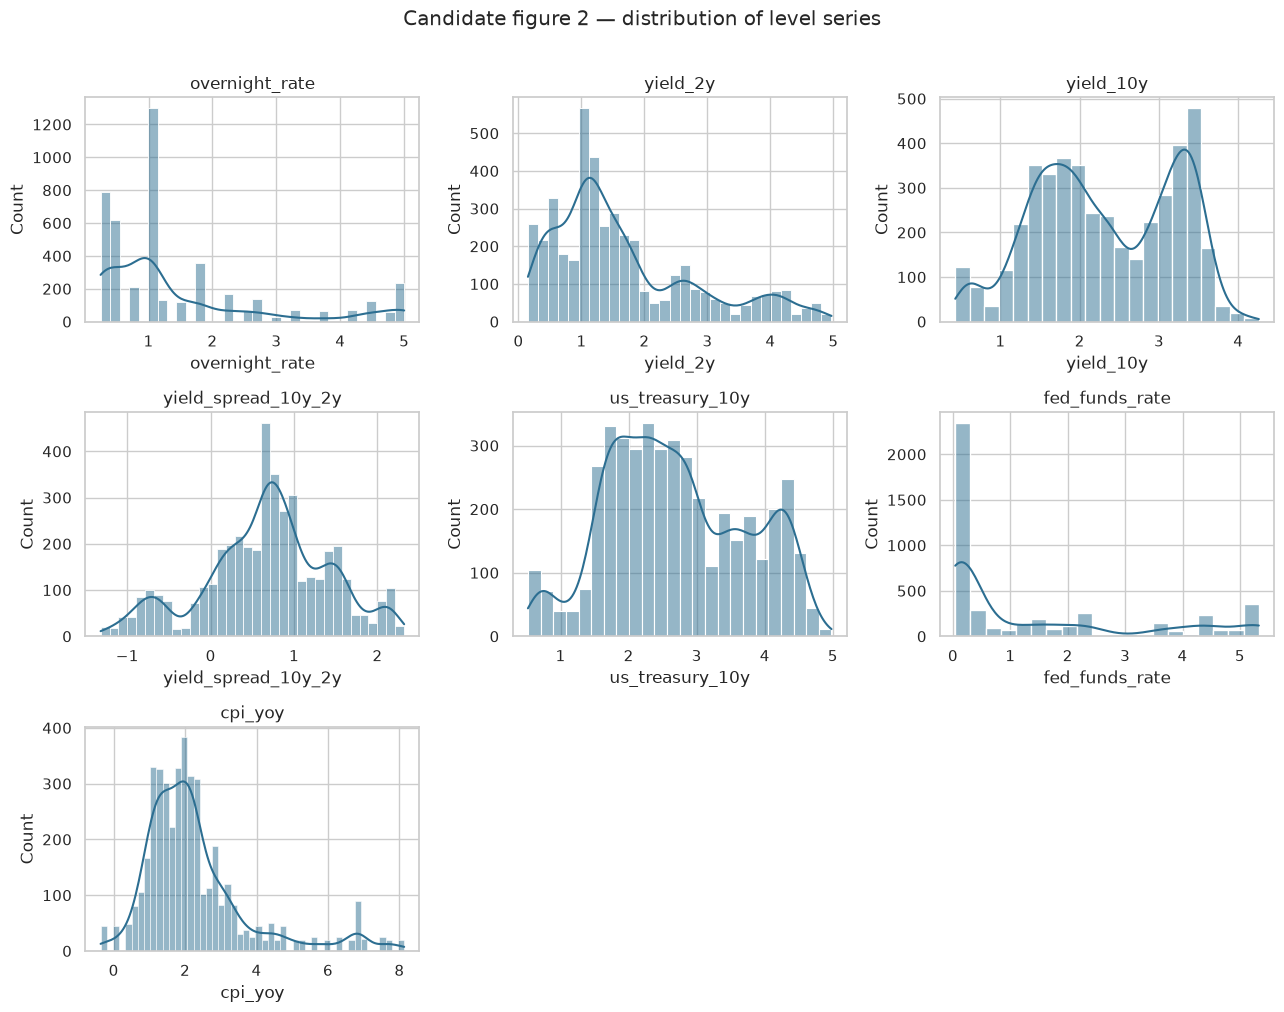

In [6]:
level_cols = [
    "overnight_rate", "yield_2y", "yield_10y", "yield_spread_10y_2y",
    "us_treasury_10y", "fed_funds_rate", "cpi_yoy",
]
fig, axes = plt.subplots(3, 3, figsize=(13, 10))
for ax, col in zip(axes.ravel(), level_cols):
    sns.histplot(daily[col].dropna(), kde=True, ax=ax, color="#2c6e91")
    ax.set_title(col)
for ax in axes.ravel()[len(level_cols):]:
    ax.axis("off")
fig.suptitle("Candidate figure 2 — distribution of level series", y=1.01)
fig.tight_layout()
plt.show()


**Interpretation:** `overnight_rate` and `fed_funds_rate` are bimodal — a long near-zero mode
(2009–2021, ZIRP-era policy) and a second mode above 4% (post-2022 hiking cycle), not a smooth
unimodal distribution. `yield_spread_10y_2y` is centered near zero but has a visible left tail —
those are the inversion episodes worth flagging for the report, not outliers to clean out.


### 🎤 Presentation readiness check — distributions

1. What's the overnight rate's full range across the whole sample? What range did it stay within
   during the 2009-2021 ZIRP era specifically, versus after 2022?
2. The Bank of Canada's inflation target band is 1-3% (midpoint 2%). Where does the latest CPI
   YoY value in this dataset sit relative to that band?
3. CPI YoY ranges from about -0.4% to +8.1% across the full sample. Which real-world period does
   the ~8% reading most plausibly correspond to, and could you defend that from this notebook
   alone or would you need to pull in another source?
4. Why does `yield_spread_10y_2y` show a left tail instead of a symmetric bell shape?

<details>
<summary>Show model answers</summary>

- **Q1:** Full range 0.25% - 5.00%. ZIRP era (2009-2021): 0.25% - 1.75%. Post-2022: up to 5.00% —
  the bimodal shape in the histogram is these two regimes sitting side by side.
- **Q2:** Latest CPI YoY ≈ 3.2%, just above the top of the 1-3% target band — inflation is
  elevated relative to target, not within it.
- **Q3:** The 2022 global inflation shock (post-COVID stimulus + supply chain disruption + energy
  prices) is the plausible driver. This notebook alone only shows the number and the date it
  occurred — the economic *cause* would need to be sourced from outside the data (e.g., BoC
  Monetary Policy Reports), which is exactly the kind of domain-context claim that shouldn't be
  asserted without a citation.
- **Q4:** The left tail is the inversion episodes — periods where the spread goes negative are
  the rare, extreme end of the distribution, not the typical case (which sits positive, near the
  historical mean).

</details>


## 6. Correlation — levels vs. first differences

Pearson correlation on **levels** of trending, non-stationary series is a well-known trap: two
unrelated random walks will show high correlation purely because both drift over time. The levels
heatmap is shown first because it's the naive thing to reach for, then the differenced version
right after — that's the one that should actually inform modeling choices.


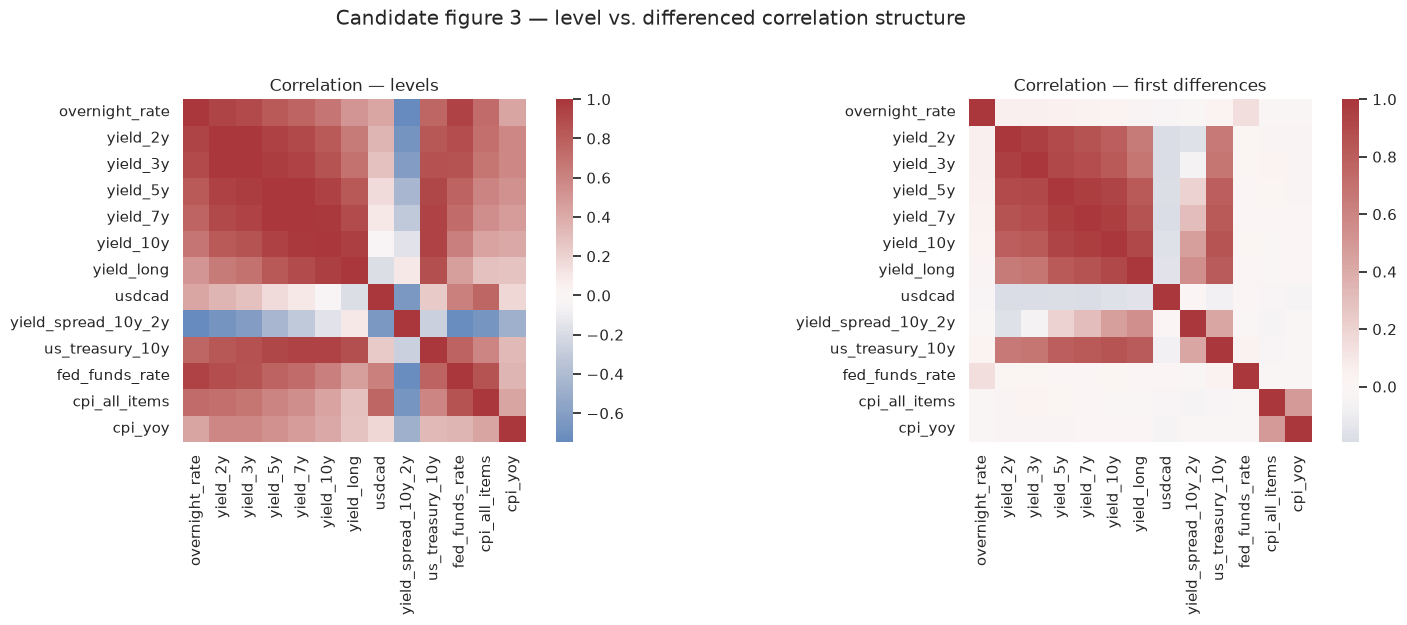

In [7]:
diff_cols = [c for c in daily.columns if c not in ("usdcad_legacy", "usdcad_current")]
levels = daily[diff_cols].dropna()
diffs = daily[diff_cols].diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(levels.corr(), cmap="vlag", center=0, ax=axes[0], square=True)
axes[0].set_title("Correlation — levels")
sns.heatmap(diffs.corr(), cmap="vlag", center=0, ax=axes[1], square=True)
axes[1].set_title("Correlation — first differences")
fig.suptitle("Candidate figure 3 — level vs. differenced correlation structure", y=1.03)
fig.tight_layout()
plt.show()


**Interpretation:** in levels, almost everything is highly correlated (>0.8) with almost
everything else — including CPI against yields, which is not a claim anyone should walk into
Round 3 modeling believing at face value. In first differences the structure is much sparser and
more plausible: the BoC yield tenors move tightly together (as expected — one curve), and
`us_treasury_10y` co-moves with `yield_10y` (US/CA rate linkage), but CPI's daily change is
essentially uncorrelated with everything, consistent with it being a step function between
monthly releases.


### 🎤 Presentation readiness check — correlation

1. `cpi_yoy` vs `yield_10y` correlates at ~0.41 in levels but drops to ~0.01 in first differences.
   Explain that gap in one sentence — what trap does it expose?
2. `yield_2y` vs `yield_10y` co-move at ~0.80 in first differences. Why would you *expect* two
   points on the same curve to move together that tightly?
3. `yield_10y` vs `us_treasury_10y` co-move at ~0.85 in first differences. What does that say
   about how connected the CAD and USD long ends are, day to day?
4. Why is it wrong to correlate CPI's daily change (flat on ~96% of days) against daily yield
   changes and conclude "CPI has no relationship to yields"?

<details>
<summary>Show model answers</summary>

- **Q1:** The 0.41 in levels is a spurious-trend artifact — two series that both drift upward
  over a long sample will look correlated even with no real link. The ~0.01 in differences is the
  more honest number: day-to-day, they're essentially unrelated at daily frequency.
- **Q2:** They're driven by the same underlying factor — the overall level of interest rates set
  by monetary policy and market expectations — so a shock that moves one tenor tends to move
  nearby tenors in the same direction, just by different amounts (that's the "level" factor a
  full PCA decomposition would later formalize).
- **Q3:** Strong cross-border linkage — Canadian and US long-term rates move together closely on
  a daily basis, consistent with globally integrated bond markets and correlated monetary policy
  cycles.
- **Q4:** CPI is a step function that only changes value ~12 times a year (on release dates); on
  every other day its daily change is exactly zero by construction. Correlating a mostly-zero
  series against daily yield noise mechanically forces the correlation toward zero — that's a
  frequency-mismatch artifact, not evidence that inflation doesn't matter to yields.

</details>


## 7. ADF stationarity pre-checks

This is the section most directly useful outside this notebook: issues #22/#23 and PRs #33/#34
are actively deciding whether VECM belongs in the model suite, and VECM only makes sense if the
underlying series are integrated (I(1)) *and* cointegrated. This table doesn't settle
cointegration (that needs a Johansen test against a specific model spec, which is Round 3's job),
but it does establish the more basic precondition: are these series even I(1) in the first place.


In [8]:
def adf_row(series, label):
    series = series.dropna()
    stat, pval, *_ = adfuller(series, autolag="AIC")
    return {"series": label, "adf_stat": round(stat, 3), "p_value": round(pval, 4),
            "stationary_at_5pct": pval < 0.05}

rows = []
for col in diff_cols:
    rows.append(adf_row(daily[col], f"{col} (level)"))
    rows.append(adf_row(daily[col].diff(), f"{col} (first diff)"))

adf_table = pd.DataFrame(rows)
adf_table


,series,adf_stat,p_value,stationary_at_5pct
0,overnight_rate (level),-1.212,0.6682,False
1,overnight_rate (first diff),-8.189,0.0000,True
2,yield_2y (level),-1.175,0.6842,False
3,yield_2y (first diff),-37.667,0.0000,True
4,yield_3y (level),-1.257,0.6484,False
5,yield_3y (first diff),-37.910,0.0000,True
6,yield_5y (level),-1.559,0.5043,False
7,yield_5y (first diff),-37.660,0.0000,True
8,yield_7y (level),-1.690,0.4362,False
9,yield_7y (first diff),-63.846,0.0000,True


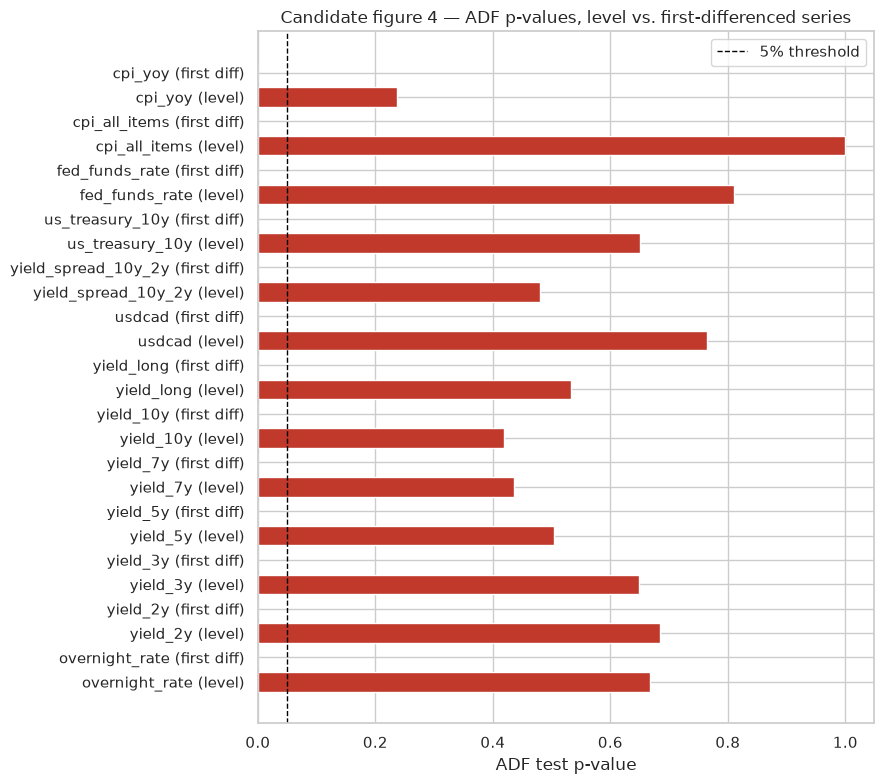

In [9]:
fig, ax = plt.subplots(figsize=(9, 8))
colors = adf_table["stationary_at_5pct"].map({True: "#2e7d32", False: "#c0392b"})
ax.barh(adf_table["series"], adf_table["p_value"], color=colors)
ax.axvline(0.05, color="black", linestyle="--", linewidth=1, label="5% threshold")
ax.set_xlabel("ADF test p-value")
ax.set_title("Candidate figure 4 — ADF p-values, level vs. first-differenced series")
ax.legend()
fig.tight_layout()
plt.show()


**Interpretation:** every level series fails to reject the unit-root null (p > 0.05) and every
first-differenced series rejects it cleanly (p ≈ 0) — the textbook I(1) pattern, and the reason
Round 3's VAR baselines need to run on differenced (or otherwise stationarity-corrected) data, not
raw levels.

One result worth being precise about rather than over-reading: `yield_spread_10y_2y` in levels
(p = 0.48) is **not** a standout — it sits inside the same 0.42–0.81 range as every other yield
level, not meaningfully lower. A spread being stationary while its components are each I(1) would
be a classic cointegration signature, but ADF on the spread alone doesn't establish that here; it
would need an actual Johansen test against a specific VAR/VECM spec, which is Round 3's job, not
something to claim off this table. Flagging it as a candidate to check in Round 3, not as a
finding.


### 🎤 Presentation readiness check — ADF stationarity

1. In plain language, what does p < 0.05 mean in an ADF test? What's the null hypothesis?
2. Every level series has p > 0.05 and every first-differenced series has p ≈ 0. What does that
   combination tell you about the order of integration of these series?
3. `yield_spread_10y_2y` has p = 0.48 in levels. Why can't that number alone be used to claim the
   spread is stationary, or that the components are cointegrated? What test would actually be
   needed?
4. Based on this table, why does Round 3's VAR baseline need to run on differenced data rather
   than raw levels?

<details>
<summary>Show model answers</summary>

- **Q1:** The null hypothesis is "this series has a unit root" (is non-stationary). p < 0.05 lets
  you reject that null — i.e., conclude the series is stationary at the 5% significance level.
- **Q2:** This is the textbook I(1) pattern — every series is non-stationary in levels but becomes
  stationary after exactly one round of differencing.
- **Q3:** p = 0.48 sits inside the same 0.42-0.81 range as every *other* level series in the
  table — it's not a standout low value that would suggest the spread is unusually stationary.
  Establishing that the spread is stationary while its components are each I(1) (the actual
  definition of cointegration) requires a Johansen test against a specific VAR/VECM
  specification, not an ADF test on the spread in isolation.
- **Q4:** Feeding non-stationary (I(1)) level data into a VAR produces spurious regression —
  apparent relationships that are really just shared trends, not real dynamics. Differencing
  makes the inputs stationary first, which is the standard precondition for VAR estimation.

</details>


## 8. Multicollinearity (VIF) — Issue #67

`data/processed/gold_features.csv` carries `yield_2y`/`yield_5y`/`yield_10y` alongside all three
pairwise spreads (`yield_spread_10y_2y`, `yield_spread_10y_5y`, `yield_spread_5y_2y`) — these
aren't just correlated, they're exact linear combinations
(`yield_spread_10y_2y === yield_10y - yield_2y === yield_spread_10y_5y + yield_spread_5y_2y`).
No VIF check exists anywhere in this repo to catch a future feature-set change that combines
columns from this dependent set. `compute_vif()` (`src/diagnostics.py`) is that check, applied
here to every feature set an actual model fits on, plus a demonstration of what it would report
if a future change re-introduced the dependency.

In [10]:
import sys
sys.path.insert(0, str(PROJECT_ROOT / "src"))
from diagnostics import compute_vif

gold = pd.read_csv(PROCESSED / "gold_features.csv", parse_dates=["date"]).set_index("date")

# VAR-AIC (#28), VAR-BIC (#29) and LSTM (#49) all fit this same differenced 6-variable set
# (src/EDA_VAR_AIC _lag _order.py's FEATURE_SET, src/lstm_baseline.py's FEATURES) -- one spread
# column, no overlapping yield levels.
diff_6var = ["d_yield_spread_10y_2y", "d_overnight_rate", "d_us_treasury_10y",
             "d_fed_funds_rate", "d_cpi_yoy", "d_usdcad"]
vif_diff_6var = compute_vif(gold, diff_6var)
vif_diff_6var

,feature,vif
0,d_us_treasury_10y,1.241306
1,d_yield_spread_10y_2y,1.233572
2,d_overnight_rate,1.023360
3,d_fed_funds_rate,1.022630
4,d_usdcad,1.009598
5,d_cpi_yoy,1.003008


In [11]:
# VECM (#47) fits in levels, both systems it actually reports (src/johansen_vecm.py's
# FEATURE_SET_5VAR/FEATURE_SET_6VAR) -- same one-spread-column shape as the differenced set above.
level_5var = ["yield_spread_10y_2y", "overnight_rate", "us_treasury_10y", "fed_funds_rate", "cpi_yoy"]
level_6var = level_5var + ["usdcad"]

vif_level_5var = compute_vif(gold, level_5var)
vif_level_6var = compute_vif(gold, level_6var)
print("5-variable system:")
display(vif_level_5var)
print("6-variable system (+ usdcad):")
display(vif_level_6var)

5-variable system:


,feature,vif
0,fed_funds_rate,16.534513
1,overnight_rate,11.118227
2,us_treasury_10y,8.810522
3,yield_spread_10y_2y,8.537717
4,cpi_yoy,1.848829


6-variable system (+ usdcad):


,feature,vif
0,fed_funds_rate,30.686877
1,overnight_rate,23.429303
2,yield_spread_10y_2y,10.161649
3,us_treasury_10y,8.821068
4,usdcad,4.490294
5,cpi_yoy,1.849146


In [12]:
# Guard demonstration, not a currently-fit feature set: what VIF reports if a future change
# combines yield levels with more than one spread column from the same dependent set.
overlapping_cols = [
    "yield_2y", "yield_5y", "yield_10y",
    "yield_spread_10y_2y", "yield_spread_10y_5y", "yield_spread_5y_2y",
]

import warnings
# Deliberately triggers a divide-by-zero inside variance_inflation_factor for the
# infinite-VIF case below -- its own RuntimeWarning traceback would otherwise leak
# the local statsmodels install path into committed output (issue #74's leak class).
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=RuntimeWarning, module="statsmodels")
    vif_overlapping = compute_vif(gold, overlapping_cols)

vif_overlapping

,feature,vif
0,yield_2y,inf
1,yield_5y,inf
2,yield_10y,inf
3,yield_spread_10y_2y,inf
4,yield_spread_10y_5y,inf
5,yield_spread_5y_2y,inf


**Interpretation:** two different results here, not one.

The **differenced** 6-variable set VAR-AIC, VAR-BIC, and LSTM all actually fit on reports VIF
between 1.00 and 1.24 for every regressor — clean, no collinearity concern.

The **level** feature sets VECM (#47) actually fits on are a different story: `fed_funds_rate`
(VIF 16.5 / 30.7 in the 5-/6-variable systems) and `overnight_rate` (11.1 / 23.4) both clear the
conventional "serious concern" threshold of 10, and `us_treasury_10y` / `yield_spread_10y_2y` sit
in the 8.5–10.2 range right at it. This is expected structurally, not a bug: these are non-stationary
I(1) level series that share common trends (multiple policy/market interest rates moving together
over the sample) — the same common-trend property Johansen/VECM is built to exploit via
cointegration, not a defect to regularize away like it would be in an ordinary OLS regression on
presumably-independent regressors. It's a genuinely different phenomenon from the exact linear
redundancy issue #67 was filed about (confirmed absent above: no current feature set combines more
than one yield/spread column), but it's real and worth the team knowing about when interpreting
VECM's β/α coefficient stability.

The **guard demonstration** confirms issue #67's specific concern: mixing yield levels with more
than one spread column from the same dependent set sends VIF to (numerically) infinity, exactly as
described. No current feature set does this — the exact-redundancy risk is real but not currently
triggered — but there's still no guard stopping a future feature-set change from re-introducing it.

## 9. Summary for the team

- **Built on:** Round 1 Path A only (Giti's PR #35) — Path B doesn't exist yet, so this isn't a
  judged comparison.
- **Yield curve overview** (section 4) shows two inversion windows in-sample — brief in 2019, then
  repeated flip-flopping across zero from mid-2022 through late 2024 — directly relevant to the
  inversion-as-leading-indicator framing in `proposal/sections/05_analytical_approach.md` §5.1. As
  of the last observation (2026-06-30) the curve is upward-sloping and not inverted.
- **CPI YoY is computed at monthly frequency** (`pct_change(12)` on the reference-month-ordered
  series, joined on `release_date`, then forward-filled) rather than `pct_change(252)` on the
  forward-filled daily series — the daily version divides by a varying count of business days per
  year and produces spurious jumps.
- **Missingness** is explainable: USD/CAD legacy/current split, CPI release-date alignment, and a
  small number of holiday-calendar mismatches. Nothing here blocks Round 3.
- **Don't correlate levels** — the differenced correlation heatmap (section 6) is the one to trust
  for any variable-selection decisions.
- **All rate/yield series are I(1)** (section 7); Round 3 VAR baselines should run on
  differences. ADF alone doesn't establish cointegration for any pair (including
  `yield_spread_10y_2y`, which is not a standout in this table) — that needs an actual Johansen
  test in Round 3, relevant to the open #22/#23 VECM discussion.
- **Round 2 team sync** (originally Fri Jul 31 per `M2_CHECKLIST.md`) has already passed as of
  this notebook — flagging so the team can confirm whether it happened and record the decision.


### 🎤 Presentation readiness check — whole notebook, cross-cutting

These are the questions most likely to come from the audience, not just the reviewer — practice
answering them out loud, not just silently:

1. Give the 90-second version: what does this notebook establish about the data before Round 3
   modeling starts, and why does the order of the sections matter (missingness → yield curve →
   distributions → correlation → stationarity)?
2. "Is the Canadian yield curve inverted right now?" — answer with a specific number, not a
   vague impression.
3. "Why should I trust the differenced correlation heatmap over just eyeballing the levels
   chart?" — answer without saying "it's more accurate," say *why*.
4. What has this EDA explicitly **not** proven yet (cointegration, ARCH effects, ACF/PACF-based
   ARIMA order, PCA factors), and why is that a deliberate scoping decision rather than a gap
   someone forgot?
5. If asked "why does the CPI calculation matter if it's just one column," what's the answer?
   (Hint: it's a candidate model feature, not a display artifact — an error there propagates
   into any downstream model that uses it.)

<details>
<summary>Show model answers</summary>

- **Q1:** The notebook establishes: which parts of the data are genuinely missing vs. missing by
  design; what the actual subject (the yield curve) looks like and where it stands today; which
  series are non-stationary in levels and therefore need differencing before any VAR/ARIMA
  modeling; and which correlations are real versus artifacts of shared trends or frequency
  mismatch. The order matters because each section's conclusion is a precondition for trusting
  the next one — you can't interpret distributions meaningfully without first knowing what's
  missing, and you can't trust a correlation number without knowing whether you're looking at
  levels or differences.
- **Q2:** No — spread is **+0.64** as of 2026-06-30, upward-sloping across every tenor.
- **Q3:** Because Pearson correlation on non-stationary, trending levels is mechanically inflated
  — two series that both drift over a 17-year sample will look highly correlated even with zero
  causal link, so the levels heatmap can't distinguish "these move together" from "these both
  went up over time."
- **Q4:** Cointegration (needs Johansen, not ADF-on-a-spread), volatility clustering (needs
  ARCH-LM), ARIMA order selection (needs ACF/PACF), and the level/slope/curvature decomposition
  (needs PCA) are all Round 3 time-series-diagnostics/modeling-stage work per
  `proposal/sections/05_analytical_approach.md` §5.2-5.3 and issue #26's definition of done for
  *this* notebook — deliberately scoped out, not overlooked, even though this notebook doesn't
  carry a standing checklist of them.
- **Q5:** `cpi_yoy` is a Gold-layer feature candidate for the VAR/VECM system per proposal §5.1 —
  if the calculation is wrong, every downstream model that uses it inherits the error, and a
  spurious jump in CPI YoY could get picked up as a false "shock" in impulse-response analysis.

</details>
